# Green Patent Detection - Advanced Agentic Workflow with QLoRA


### **Part A & B**

- Load Dataset of 50k samples
- Reuse the 100 high-risk claims using the uncertainty score from the uncertainty scores

In [1]:
# Loading dataset and libraries
import numpy as np
import pandas as pd

full_data = pd.read_parquet('patents_50k_green.parquet')
full_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               50000 non-null  int64
 1   date             50000 non-null  str  
 2   text             50000 non-null  str  
 3   Y02A             50000 non-null  int64
 4   Y02B             50000 non-null  int64
 5   Y02C             50000 non-null  int64
 6   Y02D             50000 non-null  int64
 7   Y02E             50000 non-null  int64
 8   Y02P             50000 non-null  int64
 9   Y02T             50000 non-null  int64
 10  Y02W             50000 non-null  int64
 11  is_green_silver  50000 non-null  int64
dtypes: int64(10), str(2)
memory usage: 52.7 MB


I will reuse the splits so i will just load in the splits as i have saved them as CSV's earlier. This applies to the train_silver (40k), eval_silver (5k) and the high-risk claims (100)

In [2]:
train_silver = pd.read_csv('train_silver.csv')
eval_silver = pd.read_csv('eval_silver.csv')
risk_100 = pd.read_csv('hitl_green_100.csv')

print(train_silver.info())
print(eval_silver.info())
print(risk_100.info())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               40000 non-null  int64
 1   date             40000 non-null  str  
 2   text             40000 non-null  str  
 3   Y02A             40000 non-null  int64
 4   Y02B             40000 non-null  int64
 5   Y02C             40000 non-null  int64
 6   Y02D             40000 non-null  int64
 7   Y02E             40000 non-null  int64
 8   Y02P             40000 non-null  int64
 9   Y02T             40000 non-null  int64
 10  Y02W             40000 non-null  int64
 11  is_green_silver  40000 non-null  int64
dtypes: int64(10), str(2)
memory usage: 42.2 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               5000 non-null   int64
 1   

### **Part C: The unified advanced architecture**

#### Step 1: Domain Adaptation (QLora) 

I will fine-tune a generative LLM using QLoRA on the train_silver dataset. I will complete this in AI-LAB so i have a model that is adapted to the linguistic style of patent claims. I will finetune the Mistral 7B model so it is adapted to the linguistic style of patent claims but also the logic of YO2 classifications

This will be run using a python script in the file: ´qlora_finetune.py`. We will do Parameter-Efficient-Fine-Tuning (PEFT) with the QLoRA technique. This means that i:

- Did 4bit quantization meaning that i quantizised the model weights from 16-bit to 4-bit weights. Then these 4-bit weights are frozen and used as the base knowledge. During training they are never changed

- Then i added Adapters (LoRA) where two small matrices are added next to the giant weight matrices. I add some target modules so i focus on tuning the attention layer weights the `q_proj` and `v_proj`. So during training only these added matrices are updated which means only 1-2% of the total parameters are trained. However it is the parameters that focus on which words that are most important to focus on based on the other words in a patent claim

- Lastly i did SFT (Supervised fine-tuning) where i do instruction tuning. This means i turn each row in my csv into a conversation that the model should learn from. This means that the adapters learned the mapping between the complex patent linguistic style and the Y02 classification and updated only the additional parameters in the model. 


#### Step 2: Multi-Agent System

I then set up a Multi agentic system (MAS) which i also ran through AI-LAB (`mas_classify.py`). The finetuned `Mistral 7B QlORA model` acted as the judge in the MAS, while i used the open-source model `microsoft/Phi-3-mini-4k-instruct` for both the advocate and the skeptic agents. I did not use a multi-agent framework like CrewAI or LangGraph mostly due to the fact that i used to different LLM's for the system. I will explain this more thoroughly in my report. 

Both the advocate and skeptic are prompted to provide 2 sentences arguing for and against respectively to why the patent claim refers to green technology. I have limited it to two sentences to hinder that the LLM would ramble. Then the judge is provided the raw claim and the arguments from both sides and then have to make a final verdict and also the rationale behind the decision and its confidence. We are going to use this level of confidence for the targeted human review and only focus on the claims where the Judge LLM is uncertain.

Let us look at some of the results from the MAS system:

In [7]:
mas_results = pd.read_csv('classified_results_for_hitl.csv')
print(mas_results.info())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   doc_id         100 non-null    int64  
 1   text           100 non-null    str    
 2   ai_label       100 non-null    int64  
 3   ai_confidence  100 non-null    float64
 4   ai_rationale   96 non-null     str    
dtypes: float64(1), int64(2), str(2)
memory usage: 112.1 KB
None


We can see that for 4 of the claims there is no ai_rationale. That is obviously a problem if the LLM does not provide a rationale behind its decision, and it would probably be best to let all of these go through the human review.

In [8]:
print(mas_results.head())
print(mas_results['ai_label'].value_counts())
print(mas_results['ai_confidence'].describe())

    doc_id                                               text  ai_label  \
0  9447102  1. A compound of Formula 1: wherein R is selec...         0   
1  8607927  1. A multilayer laminate for use as a flame ba...         1   
2  8984809  1. Apparatus for converting a door operator wh...         0   
3  8809354  1. A pharmaceutical composition comprising a c...         0   
4  9227385  1. A method for processing a translucent rigid...         0   

   ai_confidence                                       ai_rationale  
0       0.999000  The provided claim seems to be a chemical form...  
1       0.500000  A single material-system that can provide flam...  
2       0.003933  The proposed apparatus for converting photo-ey...  
3       0.444400                            No rationale available.  
4       0.500000  Fallback: { "label" : 1, "confidence" : 0.8997...  
ai_label
0    55
1    45
Name: count, dtype: int64
count    100.000000
mean       0.573623
std        0.255118
min        0.00000

We can see that the LLM's verdict was that 55 of the claims were non-green technology and 45 were green technology. Also if we look into the stats of the `ai_confidence`column we can see that the LLM is actually not that confident in its verdict with a mean of 57%. Let us look more into this.

Axes(0.125,0.11;0.775x0.77)
ai_confidence
0.5000    52
0.9999     5
0.9990     3
1.0000     3
0.2600     2
Name: count, dtype: int64


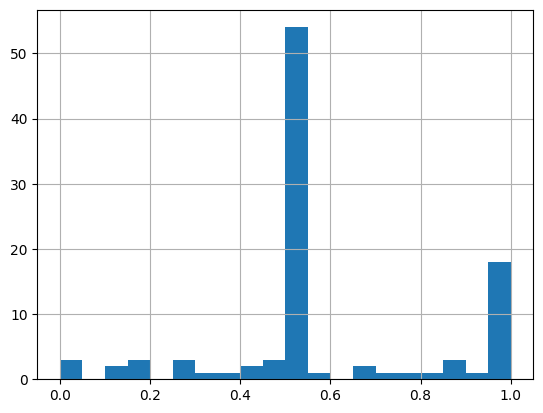

In [18]:
print(mas_results['ai_confidence'].hist(bins=20))
print(mas_results['ai_confidence'].value_counts().head(5))


So we can see a flaw based on the value_counts and the histogram of the ai-confidence-level. We have 52 claims where the ai is around 50% confident. This happens, because i built into the workflow that if the JSON parsing failed then it would manually set the confidence level to 0.5. Therefore these become a top priority for manual labelling during HITL. 

Another interesting point is that there are some examples where the ai confidence is below 50%. This could be due to a 'confused' judge where it picks one side but the opposition agent actually has a strong point and therefore the ai confidence is low for this claim. Therefore this low confidence instances are also important for human review as they may indicate the cases where the advocate and the skeptic both made good arguments and thus the LLM have become uncertain. 

Let us look into the rationale from the judge:

In [19]:
pd.set_option('display.max_colwidth', None)
mas_results['ai_rationale'].head(10)


0    The provided claim seems to be a chemical formula or a representation of a molecule. It is not in the form of a clear statement or hypothesis, making it difficult to critique or provide a critical statement accurately. It lacks sufficient context or explanation, and it is unclear whether it is a valid claim or not. In addition, the provided claim is a fragmented and unclear representation of the chemical compound, which is not enough to provide a conclusive analysis. Therefore, it is not appropriate to critique or provide a critical statement on the provided claim.
1                                                                                                                                                                                                                                           A single material-system that can provide flame resistance is not known. Moreover, the adhesive layer in this invention is capable of being activated at a relatively low temperature (75-2

We can see that the rationale column becomes quite inconsistent, however the fallback logic we've built into the code actually worked. However this could mean that we would have to engineer some of the columns.

In [23]:
mas_results.iloc[4]

doc_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

This example shows some of the problems with our results. We can see that the results is ai_label = 0 and ai_confidence = 0.5. However in the rationale we can see the actual label and confidence because it was saved by our fallback logic. However it was not built into the results directly, so the 'truth' is trapped inside the ai_rationale column. We will try to fix this with some data engineering. 

I define a function that look for the word 'Fallback' in the `ai_rationale` columns. If that word appears it look for the words 'label' and 'confidence' and the numbers related to these word for each row. Then if the function can find the words it will apply them back to them correct columns.

In [24]:
import re
import json

def repair_fallback_rows(row):
    rationale = str(row['ai_rationale'])
    
    if "Fallback:" in rationale:
        # 1. Try to find the label value
        label_match = re.search(r'"label"\s*:\s*(\d+)', rationale)
        # 2. Try to find the confidence value
        conf_match = re.search(r'"confidence"\s*:\s*([\d.]+)', rationale)
        
        if label_match:
            row['ai_label'] = int(label_match.group(1))
        if conf_match:
            row['ai_confidence'] = float(conf_match.group(1))
            
    return row

# Apply the repair to your dataframe
mas_results = mas_results.apply(repair_fallback_rows, axis=1)

# Verify the fix for doc_id 9227385
print(mas_results[mas_results['doc_id'] == 9227385][['ai_label', 'ai_confidence']])

   ai_label  ai_confidence
4         1       0.899749


So we can see that the results from the example before have changed so we now have the ai_label and confidence that was hidden in the rationale. Let us see how that affected the distribution of the data. 

ai_label
0    53
1    47
Name: count, dtype: int64
count    100.000000
mean       0.615795
std        0.352346
min        0.000000
25%        0.314785
50%        0.677375
75%        0.997727
max        1.000000
Name: ai_confidence, dtype: float64
Axes(0.125,0.11;0.775x0.77)


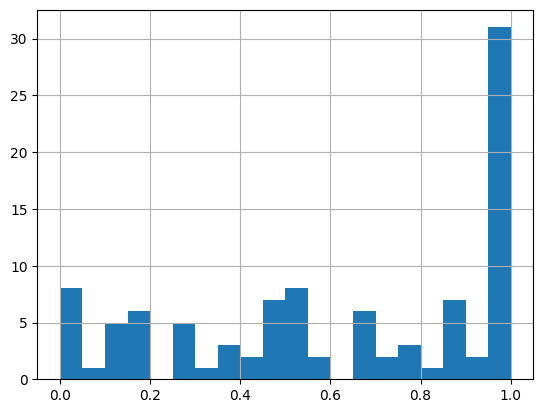

In [25]:
print(mas_results['ai_label'].value_counts())
print(mas_results['ai_confidence'].describe())
print(mas_results['ai_confidence'].hist(bins=20))

The function worked in terms of actually capturing the truth that was hidden inside the rationale column for those instances where the JSON parsing failed. Now we have a much more 'smooth' histogram with fewer instances around 0.5 confidence. Interestingly there are still plenty of claims where the LLM is below 0.5 confidence, however there are also now many instances where the LLM is fully or nearly fully confident in its verdict. We can see that by the 75-percentile of ai_confidence being at 0.99.

### **Part D:** Targeted Human Review and integration

Based on the results from the MAS, I will now build a targeted human review. This means that i will set up a HITL workflow where i will only look at the instances where the Judge is at a confidence level of 0.6 or below. First let us look at how many of the claims that is the case for.

In [30]:
review_df = mas_results[mas_results['ai_confidence'] <= 0.60]
total_to_review = len(review_df)

print(f"Total claims in the 'Uncertainty Zone' (<= 0.6): {total_to_review}")

# 2. See the distribution of labels within those uncertain cases
print("\nLabel distribution in review set:")
print(review_df['ai_label'].value_counts())



Total claims in the 'Uncertainty Zone' (<= 0.6): 48

Label distribution in review set:
ai_label
0    37
1    11
Name: count, dtype: int64


So there is actually 48 claims where the LLM os below 0.6 confidence. These will all go into the HITL workflow. 

In [ ]:
from datetime import datetime
def targeted_hitl_review(df_results):
    """
    Targeted Human-in-the-loop review: 
    - Auto-approves high confidence (> 0.6)
    - Manual review for low confidence (<= 0.6)
    """
    df = df_results.copy()
    
    # Initialize gold columns if they don't exist
    if "is_green_gold" not in df.columns:
        df["is_green_gold"] = None
        df["human_notes"] = ""
        df["reviewed_at"] = ""

    # Identify the "Uncertainty Zone"
    to_review_mask = df['ai_confidence'] <= 0.6
    num_to_review = to_review_mask.sum()
    total_claims = len(df)

    print("\n" + "="*80)
    print("TARGETED HUMAN-IN-THE-LOOP REVIEW")
    print("="*80)
    print(f"Total claims in dataset: {total_claims}")
    print(f"High Confidence (>0.6):  {total_claims - num_to_review} (Auto-approved)")
    print(f"Low Confidence (<=0.6):  {num_to_review} (Manual review required)")
    print("="*80)

    for idx, row in df.iterrows():
        # --- SKIP LOGIC ---
        if row['ai_confidence'] > 0.6:
            # Auto-assign gold label from AI label for high confidence
            df.at[idx, "is_green_gold"] = int(row["ai_label"])
            df.at[idx, "human_notes"] = "Auto-approved (High Confidence)"
            df.at[idx, "reviewed_at"] = datetime.now().isoformat()
            continue

        # --- MANUAL REVIEW LOGIC ---
        print(f"\n{'='*80}")
        print(f"LOW CONFIDENCE CLAIM — doc_id: {row['doc_id']} (Conf: {row['ai_confidence']:.2f})")
        print(f"{'='*80}")

        print(f"\nCLAIM TEXT:\n{str(row['text'])[:500]}...")

        print(f"\nAI VERDICT:")
        verdict = "GREEN (1)" if row['ai_label'] == 1 else "NOT GREEN (0)"
        print(f"   Suggestion: {verdict}")
        print(f"   Rationale: {row['ai_rationale']}")

        print(f"\nYOUR TURN (Manual Review):")
        while True:
            prompt = f"   Is this GREEN? (1=yes, 0=no, Enter=agree with AI {row['ai_label']}): "
            human_input = input(prompt).strip()
            
            if human_input == "":
                human_label = int(row["ai_label"])
                break
            elif human_input in ["0", "1"]:
                human_label = int(human_input)
                break
            else:
                print("   ⚠️ Please enter 0, 1 or press Enter to agree")

        notes = input("   Notes (optional, Enter to skip): ").strip()
        if not notes:
            notes = "Manual - confirmed" if human_label == row["ai_label"] else "Manual - corrected"

        # Update DataFrame
        df.at[idx, "is_green_gold"] = human_label
        df.at[idx, "human_notes"] = notes
        df.at[idx, "reviewed_at"] = datetime.now().isoformat()

        if human_label == row["ai_label"]:
            print("   ✓ Confirmed AI label.")
        else:
            print("   ✗ Corrected AI label.")

    # --- FINAL SUMMARY ---
    print("\n" + "="*80)
    print("HITL REVIEW COMPLETE!")
    print("="*80)
    
    agreement = (df["ai_label"] == df["is_green_gold"]).sum()
    print(f"Final Agreement Rate: {agreement}/{total_claims} ({100*agreement/total_claims:.1f}%)")
    
    return df

# --- RUN AND SAVE ---
# Use your repaired mas_results here
hitl_gold_final = targeted_hitl_review(mas_results)

# Save to the new filename as requested
hitl_gold_final.to_csv("hitl_gold_final.csv", index=False)
print("\n✅ Saved final gold dataset to: hitl_gold_final.csv")


TARGETED HUMAN-IN-THE-LOOP REVIEW
Total claims in dataset: 100
High Confidence (>0.6):  52 (Auto-approved)
Low Confidence (<=0.6):  48 (Manual review required)

LOW CONFIDENCE CLAIM — doc_id: 8607927 (Conf: 0.50)

CLAIM TEXT:
1. A multilayer laminate for use as a flame barrier comprising (i) a first polymeric film layer capable of withstanding a temperature of at least 200 C for at least 10 min, (ii) a first adhesive layer having an areal weight of from 2 to 40 gsm capable of activation at a temperature of from 75 to 200 degrees C., (iii) an inorganic refractory layer, (iv) a second adhesive layer having an areal weight of from 2 to 40 gsm capable of activation at a temperature of from 75 to 200 degrees C., and (v) a...

AI VERDICT:
   Suggestion: GREEN (1)
   Rationale: A single material-system that can provide flame resistance is not known. Moreover, the adhesive layer in this invention is capable of being activated at a relatively low temperature (75-200 C), which would limit the t

In [32]:
hitl_gold_final = pd.read_csv("hitl_gold_final.csv")
print(hitl_gold_final.info())
print(hitl_gold_final.head())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   doc_id         100 non-null    int64  
 1   text           100 non-null    str    
 2   ai_label       100 non-null    int64  
 3   ai_confidence  100 non-null    float64
 4   ai_rationale   96 non-null     str    
 5   is_green_gold  100 non-null    int64  
 6   human_notes    100 non-null    str    
 7   reviewed_at    100 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 119.4 KB
None
    doc_id  \
0  9447102   
1  8607927   
2  8984809   
3  8809354   
4  9227385   

                                                                                                                                                                                                                                                                                                                              

### **Final PatentSBERTa finetuning and model comparison**
Now after having done the HITL workflow i will finetune PatentSBERTa with the train_silver and new hitl_gold_final dataset and evaluate on the eval_silver set. This has been done using AI-LAB and the script can be found in the file: `finetune_final`. Now i will just load in the results and look at the model comparison.


In [3]:
import pandas as pd
final_model_results = pd.read_csv('eval_metrics_final.csv')
final_model_results

,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_runtime,test_samples_per_second,test_steps_per_second
0,0.483106,0.8122,0.821517,0.791575,0.853813,106.6089,46.9,1.473


We can recall the results from assignment 2 and 3 and compare the models: 

| Model Version | Training Data Source | F1 Score (Eval Set) |
|---------------|---------------------|---------------------|
| 1. Baseline | Frozen Embeddings (No Fine-tuning) | [0.78] |
| 2. Assignment 2 Model | Fine-tuned on Silver + Gold (Simple LLM) | [0.818] |
| 3. Assignment 3 Model | Fine-tuned on Silver + Gold (Agents - CrewAI) | [0.824] |
| 4. Final Assignment Model | Fine-tuned on Silver + Gold (QLoRA powered MAS + Targeted HITL) | [0.821] |